# Partial Derivatives - Part 1

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture
*"Partial derivatives - Part 1"* (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- the **mental picture**: cutting a surface into slices, each a 1D parabola with a tangent
- why the slope of that tangent **is** the partial derivative
- the **two-step recipe**: treat the other variables as constants, then differentiate normally
- the notation $f_x$ and $\dfrac{\partial f}{\partial x}$
- the worked example $f(x,y)=x^2+y^2 \Rightarrow f_x = 2x,\; f_y = 2y$
- generalization to functions of many variables
- SymPy and numerical checks, 3D visualizations, exercises, and a summary

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Introduction to Tangent Planes*.

## 1. Introduction

A **partial derivative** measures how a multivariable function changes when we vary
**one** input while holding the **others fixed**.

> *"In the cut you can see this red parabola with a tangent over there — that's the
> partial derivative."*

Partial derivatives are the building blocks of the **gradient**, and the gradient
drives **gradient descent**, the optimization engine behind most machine learning.

After this notebook you will be able to:

- picture a partial derivative as the slope of a tangent on a sliced surface
- compute partial derivatives by hand using the two-step recipe
- read and write both common notations
- verify your results with SymPy and numerically

## 2. The mental picture: slicing a surface

Take a function of two variables plotted in 3D, e.g.

$$
f(x,y) = x^2 + y^2 .
$$

Now **cut** the surface with a vertical plane. The cut reveals a **red parabola** — a
function of a *single* variable. On that parabola you can draw a tangent line, and:

> *"The slope of this line is the partial derivative."*

Cut in the **other** direction and you get a different parabola with its own tangent
(the "black tangent"). Each cutting direction gives one partial derivative.

### Fixing $y$ turns a 2D function into a 1D one

If we **fix** $y = 4$ (treat $y$ as a constant), then

$$
f(x, 4) = x^2 + 4^2 = x^2 + 16
$$

is no longer a function of two variables — it is a parabola in $x$ alone. The slope of
its tangent at a point is exactly the partial derivative with respect to $x$.

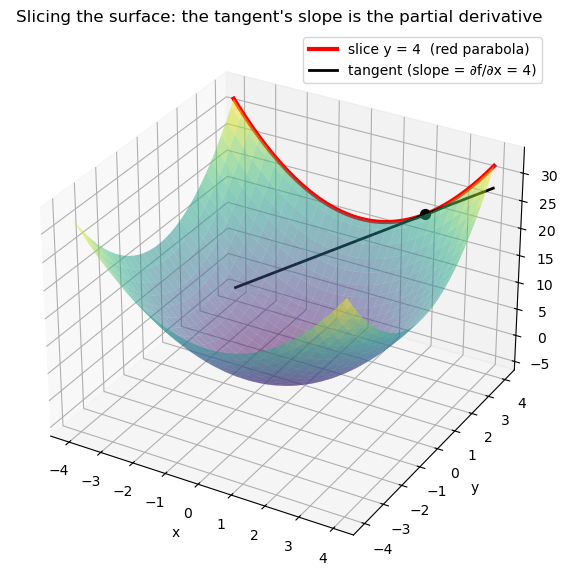

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def f(x, y):
    return x**2 + y**2

# Surface
gx = np.linspace(-4, 4, 60)
gy = np.linspace(-4, 4, 60)
X, Y = np.meshgrid(gx, gy)
Z = f(X, Y)

# A slice fixing y = 4 (the red parabola) and its tangent at x = 2
y_fix = 4.0
x0 = 2.0
xs_line = np.linspace(-4, 4, 100)
red_parabola_z = f(xs_line, y_fix)
slope_x = 2 * x0                      # ∂f/∂x at (2,4)
tangent_z = f(x0, y_fix) + slope_x * (xs_line - x0)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.5)
ax.plot(xs_line, np.full_like(xs_line, y_fix), red_parabola_z,
        color="red", linewidth=3, label="slice y = 4  (red parabola)")
ax.plot(xs_line, np.full_like(xs_line, y_fix), tangent_z,
        color="black", linewidth=2, label="tangent (slope = ∂f/∂x = 4)")
ax.scatter([x0], [y_fix], [f(x0, y_fix)], color="black", s=50)
ax.set_title("Slicing the surface: the tangent's slope is the partial derivative")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend()
plt.show()

## 3. Computing a partial derivative — the two-step recipe

> *"There are two steps. Step one: treat all the other variables as constants.
> Step two: differentiate using the normal rules of differentiation."*

For $f(x,y) = x^2 + y^2$:

**Partial derivative with respect to $x$** — treat $y$ as a constant.
Then $y^2$ behaves like any constant (think of it as $x^2 + 1$), whose derivative is $0$:

$$
\frac{\partial f}{\partial x} = \underbrace{2x}_{\text{from } x^2} + \underbrace{0}_{\text{from } y^2} = 2x .
$$

**Partial derivative with respect to $y$** — now treat $x$ as a constant
(think $1 + y^2$):

$$
\frac{\partial f}{\partial y} = \underbrace{0}_{\text{from } x^2} + \underbrace{2y}_{\text{from } y^2} = 2y .
$$

So at the point $(2, 4)$ the slice's tangent slope is $\partial f/\partial x = 2(2) = 4$,
matching the picture above.

## 4. Notation

There are two common notations for each partial derivative:

$$
\frac{\partial f}{\partial x} \;\equiv\; f_x
\qquad\qquad
\frac{\partial f}{\partial y} \;\equiv\; f_y
$$

The symbol $\partial$ ("di") is the **partial** version of the ordinary $d$.

A function of two variables has **two** partial derivatives. More generally:

> *"If I have a function not of two variables but of 10 variables, then I can take 10
> partial derivatives — one with respect to each variable."*

A function of $n$ variables has $n$ partial derivatives.

## 5. Symbolic computation with SymPy

In [2]:
x, y = sp.symbols('x y')
f_sym = x**2 + y**2

fx = sp.diff(f_sym, x)
fy = sp.diff(f_sym, y)

print("f(x, y)        =", f_sym)
print("∂f/∂x  (f_x)   =", fx)
print("∂f/∂y  (f_y)   =", fy)
print()
print("At (2, 4):  f_x =", fx.subs({x: 2, y: 4}), ", f_y =", fy.subs({x: 2, y: 4}))

f(x, y)        = x**2 + y**2
∂f/∂x  (f_x)   = 2*x
∂f/∂y  (f_y)   = 2*y

At (2, 4):  f_x = 4 , f_y = 8


### A function of many variables

The recipe scales without change. For

$$
g(x_1, x_2, x_3) = x_1^2 + 3x_1 x_2 + x_3^2,
$$

each partial derivative treats the *other* variables as constants.

In [3]:
x1, x2, x3 = sp.symbols('x1 x2 x3')
g = x1**2 + 3*x1*x2 + x3**2

for var in (x1, x2, x3):
    print(f"∂g/∂{var} =", sp.diff(g, var))

∂g/∂x1 = 2*x1 + 3*x2
∂g/∂x2 = 3*x1
∂g/∂x3 = 2*x3


## 6. Numerical check

A partial derivative is just an ordinary 1D derivative along one axis, so a central
finite difference holding the other variable fixed should reproduce it:

$$
\frac{\partial f}{\partial x}(x_0,y_0) \approx \frac{f(x_0+h,\,y_0) - f(x_0-h,\,y_0)}{2h}.
$$

In [4]:
def f(x, y):
    return x**2 + y**2

def partial_x(f, x, y, h=1e-6):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-6):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

for (x0, y0) in [(2.0, 4.0), (1.0, 3.0), (-2.0, 0.5)]:
    print(f"At ({x0:>4}, {y0:>4}): "
          f"f_x numeric={partial_x(f, x0, y0):8.5f} (exact {2*x0:5.1f}) | "
          f"f_y numeric={partial_y(f, x0, y0):8.5f} (exact {2*y0:5.1f})")

At ( 2.0,  4.0): f_x numeric= 4.00000 (exact   4.0) | f_y numeric= 8.00000 (exact   8.0)
At ( 1.0,  3.0): f_x numeric= 2.00000 (exact   2.0) | f_y numeric= 6.00000 (exact   6.0)
At (-2.0,  0.5): f_x numeric=-4.00000 (exact  -4.0) | f_y numeric= 1.00000 (exact   1.0)


## 7. Visualizing both slices and both tangents

The two partial derivatives correspond to the two cutting directions: one slice fixes
$y$ (vary $x$), the other fixes $x$ (vary $y$).

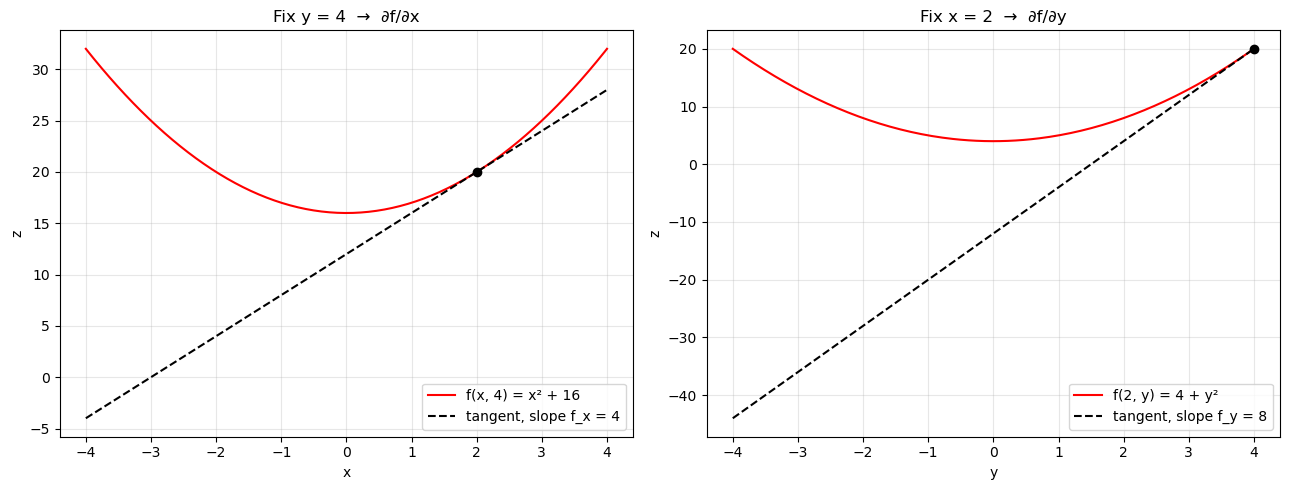

In [5]:
x0, y0 = 2.0, 4.0
t = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Slice fixing y -> parabola in x, slope f_x = 2x
axes[0].plot(t, t**2 + y0**2, "r", label="f(x, 4) = x² + 16")
sx = 2 * x0
axes[0].plot(t, (x0**2 + y0**2) + sx*(t - x0), "k--", label=f"tangent, slope f_x = {sx:.0f}")
axes[0].plot(x0, x0**2 + y0**2, "ko")
axes[0].set_title("Fix y = 4  →  ∂f/∂x"); axes[0].set_xlabel("x")

# Slice fixing x -> parabola in y, slope f_y = 2y
axes[1].plot(t, x0**2 + t**2, "r", label="f(2, y) = 4 + y²")
sy = 2 * y0
axes[1].plot(t, (x0**2 + y0**2) + sy*(t - y0), "k--", label=f"tangent, slope f_y = {sy:.0f}")
axes[1].plot(y0, x0**2 + y0**2, "ko")
axes[1].set_title("Fix x = 2  →  ∂f/∂y"); axes[1].set_xlabel("y")

for ax in axes:
    ax.set_ylabel("z"); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout()
plt.show()

## 8. Exercises

### Basic
1. For $f(x,y)=x^2+y^2$, write $f_x$ and $f_y$ from memory.
2. State the two-step recipe for computing a partial derivative in your own words.

### Intermediate
3. Compute $f_x$ and $f_y$ for $f(x,y) = 3x^2 y + y^3$.
4. For $f(x,y) = x^2 + y^2$, evaluate $f_x$ and $f_y$ at $(-1, 5)$.

### Advanced
5. Compute all three partial derivatives of
   $h(x,y,z) = x^2 y + \sin(z) + xz$.
6. Explain why, for $f(x,y)=x^2+y^2$, the partial derivative $f_x$ does **not** depend on
   the value at which $y$ was fixed. (Hint: think about what happens to the constant term
   when you differentiate.)

## 9. Solutions / Checks

In [6]:
x, y, z = sp.symbols('x y z')

f = x**2 + y**2
print("1. f_x =", sp.diff(f, x), ", f_y =", sp.diff(f, y))

g = 3*x**2*y + y**3
print("3. g_x =", sp.diff(g, x), ", g_y =", sp.diff(g, y))

print("4. at (-1, 5): f_x =", sp.diff(f, x).subs({x:-1, y:5}),
      ", f_y =", sp.diff(f, y).subs({x:-1, y:5}))

h = x**2*y + sp.sin(z) + x*z
print("5. h_x =", sp.diff(h, x), ", h_y =", sp.diff(h, y), ", h_z =", sp.diff(h, z))

print("6. f_x = 2x for every fixed y, since the y² term is a constant and "
      "its derivative w.r.t. x is 0.")

1. f_x = 2*x , f_y = 2*y
3. g_x = 6*x*y , g_y = 3*x**2 + 3*y**2
4. at (-1, 5): f_x = -2 , f_y = 10
5. h_x = 2*x*y + z , h_y = x**2 , h_z = x + cos(z)
6. f_x = 2x for every fixed y, since the y² term is a constant and its derivative w.r.t. x is 0.


## 10. Conclusion

- A **partial derivative** is the slope of the tangent to a **slice** of the surface — a
  1D problem hiding inside a multivariable function.
- The **two-step recipe**: (1) treat all other variables as constants, (2) differentiate
  with the ordinary rules.
- Notation: $\dfrac{\partial f}{\partial x} = f_x$, and likewise for each variable.
- A function of $n$ variables has $n$ partial derivatives.

Next up (*Partial derivatives - Part 2*) these partials are assembled into the
**gradient**, which points in the direction of steepest increase and is the key to
**gradient descent**.

## Appendix — Source transcript

Transcribed from the Coursera interactive transcript of
*"Partial derivatives - Part 1"*
(*Calculus for Machine Learning and Data Science*, Week 2), read via the
Claude-for-Chrome browser extension. Key spoken points, lightly cleaned:

> Picture a 3D surface cut by a plane: the cut is a red parabola, and the slope of its
> tangent is the partial derivative; cutting the other way gives another parabola and
> another tangent. Fixing $y=4$ makes $f(x,y)=x^2+y^2$ a function of $x$ alone. To take a
> partial derivative: treat the other variable as a constant, then differentiate
> normally. So $\partial f/\partial x = 2x$ (the $y^2$ term is constant, derivative $0$)
> and $\partial f/\partial y = 2y$. Notation: $f_x$ or $\partial f/\partial x$, and
> $f_y$ or $\partial f/\partial y$. A function of 10 variables has 10 partial
> derivatives — one per variable.